# Projekt 02 (medium): Einen schmutzigen Datensatz retten

**Ziel:** Ein realistisch verschmutzter Bestell-Datensatz (500 Bestellungen eines
Online-Shops) soll analysierbar gemacht werden. Du findest die Probleme **selbst**,
behandelst sie **begruendet** und weist am Ende mit einem Abnahmetest nach, dass
alles sauber ist.

**Vorbereitung** (einmalig, im Ordner `02-medium`, venv aktiv):

```
python generate_data.py
```

Die Daten sind **synthetisch** (warum, steht im Kopf von `generate_data.py`) —
aber jedes eingebaute Problem kommt so in echten Daten staendig vor.
**Nicht schummeln:** Erst selbst suchen, dann ggf. im Generator nachsehen.

**Bezug zum Skript:** Abschnitte 2.1 (Bereinigung), 2.3 (groupby), 1.4 (Boxplot).

**Arbeitsregel fuer dieses Projekt:** Zu jeder Bereinigungsentscheidung schreibst du
einen Satz Begruendung in die dafuer vorgesehenen Markdown-Zellen („Entscheidung: …").
Das ist keine Schikane — undokumentierte Bereinigung ist nicht reproduzierbar (Skript 3.3).

## 1. Sichten: Was stimmt hier alles nicht?

**Aufgabe:** Verschaffe dir mit `head()`, `info()`, `describe(include="all")` und
Stichproben einen Ueberblick und notiere in der Markdown-Zelle darunter eine Liste
aller Probleme, die du entdeckst. (Es sind mindestens 6.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

roh = pd.read_csv("datasets/bestellungen_roh.csv") if __import__("os").path.exists("datasets/bestellungen_roh.csv") \
      else pd.read_csv("../datasets/bestellungen_roh.csv")
print(roh.shape)
roh.head(8)

(515, 7)


,bestell_id,datum,stadt,kategorie,preis,menge,kunden_alter
0,10068,2024-01-13,Köln,Haushalt,"50,13 EUR",4,61
1,10204,12.08.2024,koeln,Kleidung,"117,11 EUR",3,51
2,10076,23.10.2024,Muenchen,Haushalt,"188,76 EUR",1,33
3,10313,2024-05-10,Muenchen,Buecher,"42,69 EUR",1,27
4,10483,23.09.2024,Hamburg,Buecher,"58,78 EUR",4,24
5,10441,2024-04-02,Muenchen,Elektronik,"86,02 EUR",3,76
6,10327,04.02.2024,hamburg,Elektronik,"203,45 EUR",2,64
7,10159,25.06.2024,Hamburg,Kleidung,"27,32 EUR",1,56


In [2]:
roh.info()
roh.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   bestell_id    515 non-null    int64
 1   datum         515 non-null    str  
 2   stadt         515 non-null    str  
 3   kategorie     515 non-null    str  
 4   preis         502 non-null    str  
 5   menge         515 non-null    int64
 6   kunden_alter  515 non-null    int64
dtypes: int64(3), str(4)
memory usage: 28.3 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
bestell_id,515.0,NaN,NaN,NaN,10247.013592,144.877279,10000.0,10121.5,10246.0,10372.5,10499.0
datum,515,357,12.08.2024,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stadt,515,15,Leipzig,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kategorie,515,4,Elektronik,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preis,502,481,"50,71 EUR",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
menge,515.0,NaN,NaN,NaN,3.017476,1.416168,1.0,2.0,3.0,4.0,5.0
kunden_alter,515.0,NaN,NaN,NaN,-3.574757,230.532609,-999.0,32.0,47.0,63.0,234.0


**Deine Problemliste** *(hier eintragen, bevor du weiterliest!)*:

1. …
2. …

<details><summary>Vergleich: die komplette Liste (erst nach eigener Suche aufklappen)</summary>

1. `preis` ist Text („49,99 EUR") statt Zahl — Komma & Einheit
2. fehlende Preise (leere Felder → NaN)
3. extreme Preis-Ausreisser (vierstellig+ — sieht nach Kommafehler aus)
4. `kunden_alter` enthaelt den Sondercode −999 (und mind. einen unmoeglichen Wert)
5. `stadt` inkonsistent: Gross-/Kleinschreibung, Leerzeichen, Umlaut-Varianten
6. `datum` in zwei Formaten gemischt (ISO und deutsch)
7. Duplikat-Zeilen (515 Zeilen, aber nur 500 verschiedene `bestell_id`s?)
</details>

## 2. Duplikate

**Aufgabe:** Wie viele exakte Duplikate gibt es? Entferne sie (Ergebnis: `df`).
Pruefe danach, ob auch `bestell_id` eindeutig ist (sonst gaebe es Fast-Duplikate).

In [3]:
print("exakte Duplikate:", roh.duplicated().sum())
df = roh.drop_duplicates().copy()
print("eindeutige IDs:", df["bestell_id"].is_unique)
print("Zeilen:", len(df))   # erwartet: 500

exakte Duplikate: 15
eindeutige IDs: True
Zeilen: 500


**Entscheidung:** Exakte Duplikate entfernt (15 Stueck) — identische Zeilen inkl.
Bestell-ID koennen keine echten Zweitbestellungen sein, sondern sind ein Exportfehler.

## 3. Preis: Text → Zahl, fehlende Werte

**Aufgabe:** Erzeuge eine numerische Spalte `preis_eur` (Einheit entfernen, Komma →
Punkt, `astype(float)` — leere Felder sollen automatisch `NaN` werden).
Wie viele Preise fehlen?

In [4]:
df["preis_eur"] = (df["preis"].str.replace(" EUR", "", regex=False)
                              .str.replace(",", ".", regex=False)
                              .astype(float))
print("fehlende Preise:", df["preis_eur"].isna().sum())   # erwartet: 12

fehlende Preise: 12


**Entscheidung:** Die 12 fehlenden Preise bleiben `NaN` (kein Imputieren): Es sind
nur 2,4 % der Zeilen, pandas-Aggregationen ignorieren NaN automatisch, und einen
Bestellpreis mit dem Median aufzufuellen wuerde eine Genauigkeit vortaeuschen,
die wir nicht haben.

## 4. Ausreisser — die Lieblingsfalle

**Aufgabe (a):** Wende die IQR-Regel (Skript 2.1) auf `preis_eur` **global** an.
Wie viele Zeilen werden markiert? Schau dir die markierten Preise an — sind das
alles Fehler?

In [5]:
q1, q3 = df["preis_eur"].quantile([0.25, 0.75])
iqr = q3 - q1
obere_grenze = q3 + 1.5 * iqr
maske_global = df["preis_eur"] > obere_grenze
print(f"obere Grenze: {obere_grenze:.2f} EUR — markiert: {maske_global.sum()} Zeilen")
print(df.loc[maske_global, "preis_eur"].sort_values().values)

obere Grenze: 288.21 EUR — markiert: 41 Zeilen
[  288.72   296.29   299.91   307.35   308.54   313.14   314.74   318.89
   318.98   320.47   322.43   325.07   325.48   327.6    337.15   338.85
   343.76   348.56   348.9    351.63   353.26   360.02   361.59   368.86
   371.47   372.02   372.81   373.18   375.14   380.62   380.85   382.14
   385.36   387.99   389.78   389.8    391.62   392.75  1321.   18363.
 19685.  ]


**41 markierte Zeilen — aber nur 3 sehen wirklich kaputt aus** (vierstellig+).
Der Rest sind teure, aber plausible Elektronik-Preise. Die globale IQR-Regel
vergleicht Buecher mit Fernsehern — unfair. Der Boxplot pro Kategorie zeigt das Problem:

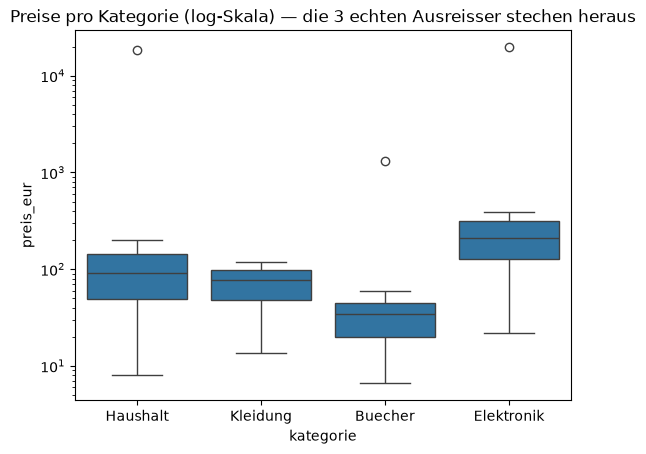

In [6]:
import seaborn as sns
sns.boxplot(data=df, x="kategorie", y="preis_eur")
plt.yscale("log")   # log-Skala, sonst quetschen die Ausreisser alles zusammen
plt.title("Preise pro Kategorie (log-Skala) — die 3 echten Ausreisser stechen heraus")
plt.show()

**Aufgabe (b):** Wende die IQR-Regel **pro Kategorie** an
(Tipp: `df.groupby("kategorie")["preis_eur"].transform(...)` mit einer Funktion,
die je Gruppe die obere Grenze liefert). Jetzt sollten genau **3** Zeilen markiert
werden. Korrigiere sie: Es sind offensichtlich Kommafehler (Faktor 100) → teile durch 100.

In [7]:
def obere_iqr_grenze(g):
    q1, q3 = g.quantile([0.25, 0.75])
    return q3 + 1.5 * (q3 - q1)

grenzen = df.groupby("kategorie")["preis_eur"].transform(obere_iqr_grenze)
maske = df["preis_eur"] > grenzen
print(f"markiert: {maske.sum()} Zeilen")
print(df.loc[maske, ["bestell_id", "kategorie", "preis_eur"]])
df.loc[maske, "preis_eur"] = df.loc[maske, "preis_eur"] / 100
print("neuer Maximalpreis:", df["preis_eur"].max().round(2))

markiert: 3 Zeilen
     bestell_id   kategorie  preis_eur
256       10092     Buecher     1321.0
264       10262  Elektronik    19685.0
475       10282    Haushalt    18363.0
neuer Maximalpreis: 392.75


**Entscheidung:** 3 Preise (1321 / 18363 / 19685 EUR) als Kommafehler eingestuft und
durch 100 geteilt — Begruendung: Sie liegen um genau zwei Groessenordnungen ueber dem
Kategorie-Ueblichen, und nach der Korrektur passen sie unauffaellig ins Preisband.
*(Im echten Leben wuerde man zusaetzlich im Quellsystem nachpruefen.)*
Beachte den Dreiklang aus Skript 2.1: Fehler → korrigieren; echter Extremwert →
behalten; Sondercode → NaN. Hier lagen Fehler vor — die teuren Fernseher von
oben waren dagegen echte Extremwerte und bleiben unangetastet!

## 5. Staedte normalisieren

**Aufgabe:** `df["stadt"].value_counts()` zeigt das Chaos. Erzeuge `stadt_sauber`:
Leerzeichen weg, Kleinschreibung, Umlautvarianten vereinheitlichen
(`münchen`→`muenchen`, `köln`→`koeln`), dann `str.capitalize()`.
Am Ende: genau **5** verschiedene Staedte.

In [8]:
print(df["stadt"].value_counts())
df["stadt_sauber"] = (df["stadt"].str.strip().str.lower()
                      .replace({"münchen": "muenchen", "köln": "koeln"})
                      .str.capitalize())
print("\nnachher:", sorted(df["stadt_sauber"].unique()))
print("Anzahl:", df["stadt_sauber"].nunique())   # erwartet: 5

stadt
Leipzig     54
leipzig     46
Köln        38
Hamburg     38
Muenchen    36
koeln       35
München     34
hamburg     32
Berlin      32
Hamburg     29
berlin      29
Koeln       29
 Berlin     26
muenchen    21
BERLIN      21
Name: count, dtype: int64

nachher: ['Berlin', 'Hamburg', 'Koeln', 'Leipzig', 'Muenchen']
Anzahl: 5


## 6. Alter: Sondercode und Plausibilitaet

**Aufgabe:** `df["kunden_alter"].describe()` verraet zwei Probleme (min und max
anschauen!). Erzeuge `alter`: den Sondercode **−999** („keine Angabe") durch `NaN`
ersetzen und unplausible Alter (> 100) ebenfalls auf `NaN` setzen.

In [9]:
print(df["kunden_alter"].describe().round(1))
df["alter"] = df["kunden_alter"].replace(-999, np.nan)
df.loc[df["alter"] > 100, "alter"] = np.nan
print("\nfehlend:", df["alter"].isna().sum(), "| Bereich:", df["alter"].min(), "-", df["alter"].max())

count    500.0
mean      -3.3
std      229.4
min     -999.0
25%       32.0
50%       47.0
75%       62.0
max      234.0
Name: kunden_alter, dtype: float64

fehlend: 26 | Bereich: 18.0 - 79.0


**Entscheidung:** −999 ist offensichtlich ein „keine Angabe"-Code (25×) → NaN.
Das Alter 234 ist physisch unmoeglich, der wahre Wert unrekonstruierbar → NaN
statt raten. Insgesamt 26 fehlende Alter (5,2 %) — fuer Analysen nach Alter
werden diese Zeilen automatisch ausgelassen, der Rest des Datensatzes bleibt nutzbar.

## 7. Datum: zwei Formate, eine Spalte

**Aufgabe:** `pd.to_datetime` mit festem `format` und `errors="coerce"` parst nur
das passende Format (Rest wird NaT). Parse beide Formate getrennt und fuege sie mit
`fillna` zusammen. Am Ende: **0** NaT-Werte.

In [10]:
iso = pd.to_datetime(df["datum"], format="%Y-%m-%d", errors="coerce")
deutsch = pd.to_datetime(df["datum"], format="%d.%m.%Y", errors="coerce")
df["datum_sauber"] = iso.fillna(deutsch)
print("nicht parsebar:", df["datum_sauber"].isna().sum())   # erwartet: 0
print(df["datum_sauber"].min(), "bis", df["datum_sauber"].max())

nicht parsebar: 0
2024-01-02 00:00:00 bis 2024-12-28 00:00:00


## 8. Abnahmetest

Diese Zelle ist fertig vorgegeben. Laeuft sie ohne Fehler durch, ist dein Datensatz
offiziell sauber.

In [11]:
sauber = df[["bestell_id", "datum_sauber", "stadt_sauber", "kategorie",
             "preis_eur", "menge", "alter"]].rename(
                 columns={"datum_sauber": "datum", "stadt_sauber": "stadt"})

assert len(sauber) == 500, "Duplikate nicht (richtig) entfernt"
assert sauber["bestell_id"].is_unique
assert sauber["preis_eur"].dtype == float and sauber["preis_eur"].isna().sum() == 12
assert sauber["preis_eur"].max() < 500, "Preis-Ausreisser nicht korrigiert"
assert sauber["stadt"].nunique() == 5, "Staedte nicht vollstaendig normalisiert"
assert sauber["alter"].isna().sum() == 26 and sauber["alter"].max() <= 100
assert str(sauber["datum"].dtype).startswith("datetime64") and sauber["datum"].isna().sum() == 0
assert abs(sauber["preis_eur"].median() - 71.6) < 0.5, "Preise stimmen nicht (Korrektur pruefen)"

print("ABNAHME BESTANDEN — Datensatz ist sauber. 🎉")
sauber.head()

ABNAHME BESTANDEN — Datensatz ist sauber. 🎉


,bestell_id,datum,stadt,kategorie,preis_eur,menge,alter
0,10068,2024-01-13,Koeln,Haushalt,50.13,4,61.0
1,10204,2024-08-12,Koeln,Kleidung,117.11,3,51.0
2,10076,2024-10-23,Muenchen,Haushalt,188.76,1,33.0
3,10313,2024-05-10,Muenchen,Buecher,42.69,1,27.0
4,10483,2024-09-23,Hamburg,Buecher,58.78,4,24.0


## 9. Belohnung: die erste echte Analyse

Jetzt, wo die Daten sauber sind, ist die Analyse ein Dreizeiler — fertig vorgegeben.

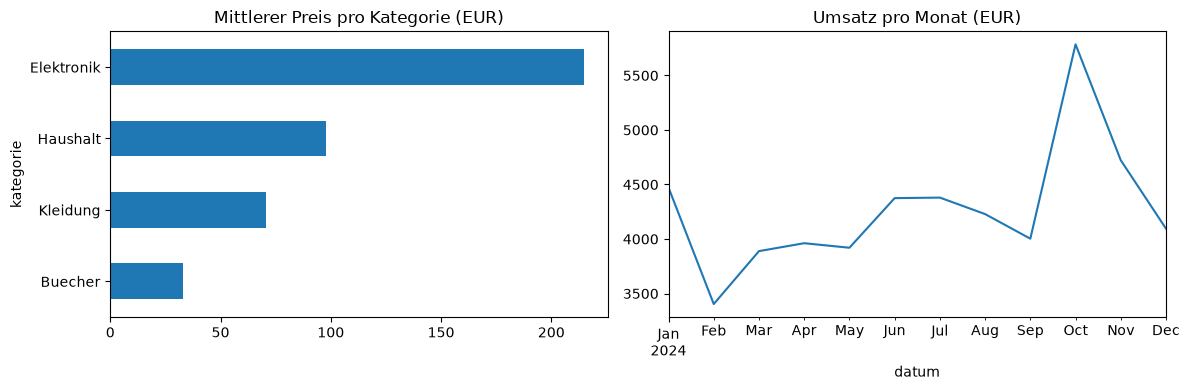

,bestellungen,umsatz,mittleres_alter
stadt,,,
Berlin,108,9674.1,47.2
Hamburg,99,9819.9,48.9
Koeln,102,10754.6,48.4
Leipzig,100,11063.3,50.3
Muenchen,91,9924.0,49.0


In [12]:
fig, achsen = plt.subplots(1, 2, figsize=(12, 4))
sauber.groupby("kategorie")["preis_eur"].mean().sort_values().plot.barh(ax=achsen[0])
achsen[0].set_title("Mittlerer Preis pro Kategorie (EUR)")
sauber.set_index("datum").resample("ME")["preis_eur"].sum().plot(ax=achsen[1])
achsen[1].set_title("Umsatz pro Monat (EUR)")
plt.tight_layout(); plt.show()

sauber.groupby("stadt").agg(bestellungen=("bestell_id", "count"),
                            umsatz=("preis_eur", "sum"),
                            mittleres_alter=("alter", "mean")).round(1)

## Geschafft — was du jetzt kannst

- Datenprobleme systematisch *finden* statt nur beheben
- Typkonvertierung, Duplikate, Sondercodes, Textnormalisierung, gemischte Datumsformate
- die IQR-Regel richtig einsetzen — inklusive der Lektion, dass sie **pro Gruppe**
  angewendet werden muss, wenn die Gruppen verschiedene Skalen haben
- Bereinigungsentscheidungen dokumentieren und per Abnahmetest absichern

**Bonusaufgaben** (optional):
1. Oeffne `generate_data.py` und vergleiche: Hast du alle eingebauten Probleme gefunden?
2. Aendere im Generator den Seed — laeuft dein Notebook trotzdem durch? (Die
   Abnahme-Zahlen aendern sich; welche Pruefungen sind seed-unabhaengig formulierbar?)
3. Baue eine Funktion `bereinige(df_roh)`, die alle Schritte kapselt — der erste
   Schritt von der Analyse zur wiederverwendbaren Pipeline.